create visualization of METR data, from https://metr.org/assets/benchmark_results_1_1.yaml

In [1]:
import yaml

# Load the YAML data
with open('../data/metr/benchmark_results_1_1.yaml', 'r') as f:
    data = yaml.safe_load(f)

data

{'benchmark_name': 'METR-Horizon-v1.1',
 'doubling_time_in_days': {'all_time_stitched': {'point_estimate': 188.657},
  'from_2023_on': {'ci_high': 155.27,
   'ci_low': 105.213,
   'point_estimate': 128.12}},
 'long_tasks_version': '799cc9c4b4483a93fc3445623a49ea1bd74fdeb2',
 'results': {'claude_3_5_sonnet_20240620_inspect': {'benchmark_name': 'METR-Horizon-v1.1',
   'metrics': {'average_score': {'estimate': 0.401502},
    'is_sota': True,
    'p50_horizon_length': {'ci_high': 20.892402,
     'ci_low': 4.726563,
     'estimate': 10.771603},
    'p80_horizon_length': {'ci_high': 3.41568,
     'ci_low': 0.415714,
     'estimate': 1.319663},
    'usage': {'usd': 0.0, 'working_time': 20649.812666666672}},
   'release_date': datetime.date(2024, 6, 20),
   'scaffolds': ['mtb/start_metr_task,metr_agents/react',
    'ai_rd_fix_embedding/init_solver,use_tools,metr_agents/react',
    're_bench_common/init_solver,use_tools,metr_agents/react',
    'metr_tasks_swaa/init_solver,generate',
    'metr_a

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from matplotlib.ticker import FuncFormatter

# Configuration: Choose metric to plot ('p50' or 'p80')
METRIC = 'p80'  # Change to 'p80' to plot p80_horizon_length instead
metric_key = f'{METRIC}_horizon_length'

# Extract data from the YAML
models_data = []
for model_name, model_info in data['results'].items():
    if 'metrics' in model_info and metric_key in model_info['metrics']:
        metric_data = model_info['metrics'][metric_key]
        release_date = model_info['release_date']
        if isinstance(release_date, str):
            release_date = datetime.strptime(release_date, '%Y-%m-%d')
        else:
            release_date = datetime.combine(release_date, datetime.min.time())
        
        models_data.append({
            'name': model_name,
            'date': release_date,
            'estimate': metric_data['estimate'] / 60,  # Convert minutes to hours
            'ci_low': metric_data.get('ci_low', metric_data['estimate']) / 60,  # Convert to hours
            'ci_high': metric_data.get('ci_high', metric_data['estimate']) / 60,  # Convert to hours
            'is_sota': model_info['metrics'].get('is_sota', False)
        })

# Sort by date
models_data.sort(key=lambda x: x['date'])


In [3]:
# Check GPT-5.2 specifically
gpt52_data = [m for m in models_data if 'gpt_5_2' in m['name'] and m['name'] == 'gpt_5_2'][0]
print(f"GPT-5.2 {METRIC} data:")
print(f"  Estimate: {gpt52_data['estimate']} hours")
print(f"  Estimate in minutes: {gpt52_data['estimate'] * 60:.2f} minutes")
print(f"  CI Low: {gpt52_data['ci_low']} hours")
print(f"  CI High: {gpt52_data['ci_high']} hours")
print(f"\nRaw data from YAML:")
print(data['results']['gpt_5_2']['metrics'][f'{METRIC}_horizon_length'])

GPT-5.2 p80 data:
  Estimate: 0.9189011166666667 hours
  Estimate in minutes: 55.13 minutes
  CI Low: 0.44939781666666667 hours
  CI High: 1.79438515 hours

Raw data from YAML:
{'ci_high': 107.663109, 'ci_low': 26.963869, 'estimate': 55.134067}


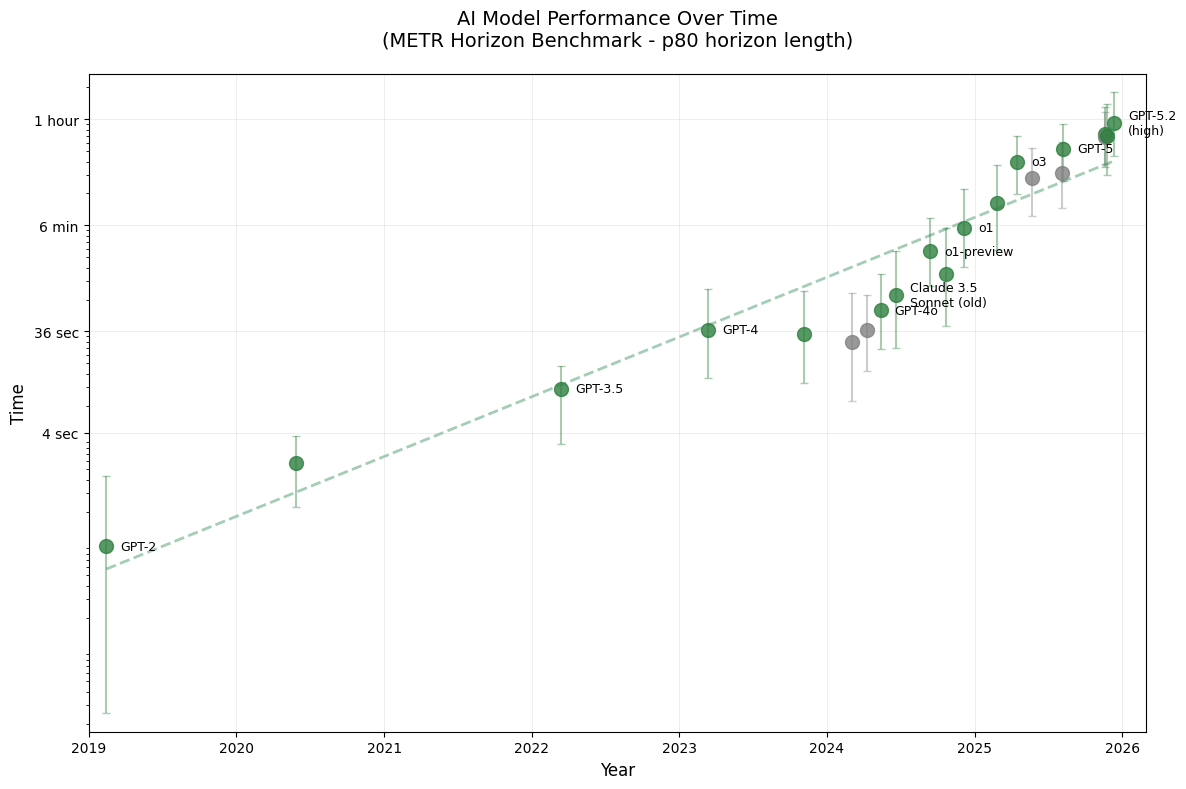

In [4]:

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data for plotting
dates = [m['date'] for m in models_data]
estimates = [m['estimate'] for m in models_data]
ci_lows = [m['ci_low'] for m in models_data]
ci_highs = [m['ci_high'] for m in models_data]
is_sota = [m['is_sota'] for m in models_data]

# Calculate error bars (estimates - ci_low, ci_high - estimates)
yerr_lower = [est - low for est, low in zip(estimates, ci_lows)]
yerr_upper = [high - est for est, high in zip(estimates, ci_highs)]

# Plot points with different colors for SOTA vs non-SOTA
for i, (date, est, sota, name) in enumerate(zip(dates, estimates, is_sota, [m['name'] for m in models_data])):
    color = '#2d7f3e' if sota else '#808080'  # Green for SOTA, gray for non-SOTA
    ax.scatter(date, est, c=color, s=100, zorder=3, alpha=0.8)
    
    # Add error bars
    ax.errorbar(date, est, 
                yerr=[[yerr_lower[i]], [yerr_upper[i]]], 
                fmt='none', 
                ecolor=color, 
                alpha=0.4, 
                capsize=3,
                zorder=2)

# Add trend line for SOTA models
sota_dates = [m['date'] for m in models_data if m['is_sota']]
sota_estimates = [m['estimate'] for m in models_data if m['is_sota']]

if len(sota_dates) > 1:
    # Convert dates to numeric values for regression
    date_nums = np.array([(d - min(sota_dates)).days for d in sota_dates])
    log_estimates = np.log(sota_estimates)
    
    # Fit exponential trend (linear in log space)
    z = np.polyfit(date_nums, log_estimates, 1)
    p = np.poly1d(z)
    
    # Generate trend line
    all_date_nums = np.array([(d - min(sota_dates)).days for d in dates])
    trend_dates = dates
    trend_values = np.exp(p(all_date_nums))
    
    ax.plot(trend_dates, trend_values, '--', color='#7eb896', linewidth=2, alpha=0.7, zorder=1)

# Set logarithmic scale on y-axis
ax.set_yscale('log')

# Format y-axis with time labels
def format_time(y, pos):
    """Format y-axis labels as time durations"""
    hours = y
    if hours < 1/60:  # Less than 1 minute
        seconds = hours * 3600
        return f'{seconds:.0f} sec'
    elif hours < 1:  # Less than 1 hour
        minutes = hours * 60
        return f'{minutes:.0f} min'
    else:
        return f'{hours:.0f} hour' + ('s' if hours != 1 else '')

ax.yaxis.set_major_formatter(FuncFormatter(format_time))

# Set y-axis limits and ticks dynamically based on data
max_value = max(ci_highs)  # Use max of confidence intervals for upper bound
min_value = min(ci_lows)   # Use min of confidence intervals for lower bound

# Add padding (in log space, tighter)
y_max = max_value * 1.5  # Upper padding
y_min = min_value / 1.5  # Lower padding

# Generate appropriate tick marks based on the range
all_ticks = [1/900, 1/100, 1/10, 1, 10, 100, 1000]
ticks = [t for t in all_ticks if y_min <= t <= y_max]

# Ensure we have at least 3 ticks
if len(ticks) < 3:
    # Extend range slightly if needed
    y_min = all_ticks[max(0, all_ticks.index(ticks[0]) - 1)]
    y_max = all_ticks[min(len(all_ticks) - 1, all_ticks.index(ticks[-1]) + 1)]
    ticks = [t for t in all_ticks if y_min <= t <= y_max]

ax.set_ylim([y_min, y_max])
ax.set_yticks(ticks)

# Format x-axis
ax.set_xlim([datetime(2019, 1, 1), datetime(2026, 3, 1)])

# Labels and title
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Time', fontsize=12)
ax.set_title(f'AI Model Performance Over Time\n(METR Horizon Benchmark - {METRIC} horizon length)', 
             fontsize=14, pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Add model labels for key models
label_models = {
    'gpt2': 'GPT-2',
    'gpt_3_5_turbo_instruct': 'GPT-3.5',
    'gpt_4': 'GPT-4',
    'gpt_4o_inspect': 'GPT-4o',
    'claude_3_5_sonnet_20240620_inspect': 'Claude 3.5\nSonnet (old)',
    'o1_preview': 'o1-preview',
    'o1_inspect': 'o1',
    'o3_inspect': 'o3',
    'gpt_5_2025_08_07_inspect': 'GPT-5',
    'gpt_5_2': 'GPT-5.2\n(high)'
}

for m in models_data:
    if m['name'] in label_models:
        ax.annotate(label_models[m['name']], 
                   xy=(m['date'], m['estimate']),
                   xytext=(10, 0), 
                   textcoords='offset points',
                   fontsize=9,
                   va='center')

plt.tight_layout()
plt.savefig('../../book/book/images/metr_horizon_benchmark.png', dpi=300)
plt.show()

In [8]:
# Calculate doubling time for data from 2023 onwards
from datetime import datetime

# Filter for SOTA models from 2023 onwards
cutoff_date = datetime(2024, 1, 1)
recent_sota = [m for m in models_data if m['is_sota'] and m['date'] >= cutoff_date]

if len(recent_sota) >= 2:
    # Sort by date
    recent_sota.sort(key=lambda x: x['date'])
    
    # Extract dates and estimates
    recent_dates = [m['date'] for m in recent_sota]
    recent_estimates = [m['estimate'] for m in recent_sota]
    
    # Convert dates to days since first observation
    days_since_start = np.array([(d - recent_dates[0]).days for d in recent_dates])
    
    # Fit exponential model: y = a * exp(b * t)
    # In log space: log(y) = log(a) + b * t
    log_estimates = np.log(recent_estimates)
    
    # Linear regression in log space
    coeffs = np.polyfit(days_since_start, log_estimates, 1)
    growth_rate_per_day = coeffs[0]  # This is b in the equation above
    
    # Doubling time: time for performance to double
    # If y(t) = a * exp(b * t), then y(t + T_double) = 2 * y(t)
    # exp(b * T_double) = 2
    # T_double = ln(2) / b
    doubling_time_days = np.log(2) / growth_rate_per_day
    
    print(f"Performance doubling time analysis (from {cutoff_date.year} onwards):")
    print(f"  Metric: {METRIC} horizon length")
    print(f"  Number of SOTA models in period: {len(recent_sota)}")
    print(f"  Date range: {recent_dates[0].strftime('%Y-%m-%d')} to {recent_dates[-1].strftime('%Y-%m-%d')}")
    print(f"  Growth rate: {growth_rate_per_day:.6f} per day ({growth_rate_per_day * 365:.4f} per year)")
    print(f"  Doubling time: {doubling_time_days:.1f} days ({doubling_time_days / 30:.1f} months)")
    print(f"\nModels included:")
    for m in recent_sota:
        print(f"  - {m['name']}: {m['estimate']*60:.1f} min ({m['date'].strftime('%Y-%m-%d')})")
else:
    print(f"Not enough SOTA models from {cutoff_date.year} onwards to calculate doubling time (found {len(recent_sota)})")

Performance doubling time analysis (from 2024 onwards):
  Metric: p80 horizon length
  Number of SOTA models in period: 11
  Date range: 2024-05-13 to 2025-12-11
  Growth rate: 0.006910 per day (2.5220 per year)
  Doubling time: 100.3 days (3.3 months)

Models included:
  - gpt_4o_inspect: 0.9 min (2024-05-13)
  - claude_3_5_sonnet_20240620_inspect: 1.3 min (2024-06-20)
  - o1_preview: 3.4 min (2024-09-12)
  - claude_3_5_sonnet_20241022_inspect: 2.1 min (2024-10-22)
  - o1_inspect: 5.7 min (2024-12-05)
  - claude_3_7_sonnet_inspect: 9.8 min (2025-02-24)
  - o3_inspect: 23.9 min (2025-04-16)
  - gpt_5_2025_08_07_inspect: 31.6 min (2025-08-07)
  - gemini_3_pro: 43.4 min (2025-11-18)
  - claude_opus_4_5_inspect: 41.6 min (2025-11-24)
  - gpt_5_2: 55.1 min (2025-12-11)
